<a href="https://colab.research.google.com/github/di-claro-batera/faculdade_data_science/blob/main/Compara%C3%A7%C3%A3o_Classifica%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, RocCurveDisplay
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize']=[15,10]
plt.rcParams.update({'font.size': 18})

In [3]:
url = 'https://raw.githubusercontent.com/higoramario/univesp-com410-aprendizado-de-maquinas/main/vinhos-binario.csv'
vinhos = pd.read_csv(url, sep=',')
vinhos.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,0
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,0
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,1
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,1
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,0


In [4]:
vinhos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
vinhos_atributos = vinhos.iloc[:,:11]
vinhos_classes = vinhos['quality']

In [6]:
vinhos_treino, vinhos_teste, classes_treino, classes_teste = train_test_split(vinhos_atributos, vinhos_classes, test_size=0.1)

In [7]:
scaler = StandardScaler()
vinhos_treino = scaler.fit_transform(vinhos_treino)
vinhos_teste = scaler.transform(vinhos_teste)

usando o k Nearest Neighbors

In [8]:
modelo_kNN = KNeighborsClassifier(n_neighbors=20)
modelo_kNN.fit(vinhos_treino, classes_treino)

KNeighborsClassifier(n_neighbors=20)

In [10]:
predicao_kNN = modelo_kNN.predict(vinhos_teste)
acuracia_kNN = accuracy_score(classes_teste, predicao_kNN)
print('Acuracia de classificação k-NN: {}'.format(round(acuracia_kNN, 3)*100)+'%')

Acuracia de classificação k-NN: 69.39999999999999%


In [11]:
print(classification_report(classes_teste, predicao_kNN))

              precision    recall  f1-score   support

           0       0.68      0.70      0.69        77
           1       0.71      0.69      0.70        83

    accuracy                           0.69       160
   macro avg       0.69      0.69      0.69       160
weighted avg       0.69      0.69      0.69       160



In [12]:
cross_val_score(modelo_kNN, vinhos_treino, classes_treino, cv=10)

array([0.72222222, 0.71527778, 0.66666667, 0.74305556, 0.76388889,
       0.80555556, 0.72916667, 0.75694444, 0.73611111, 0.71328671])

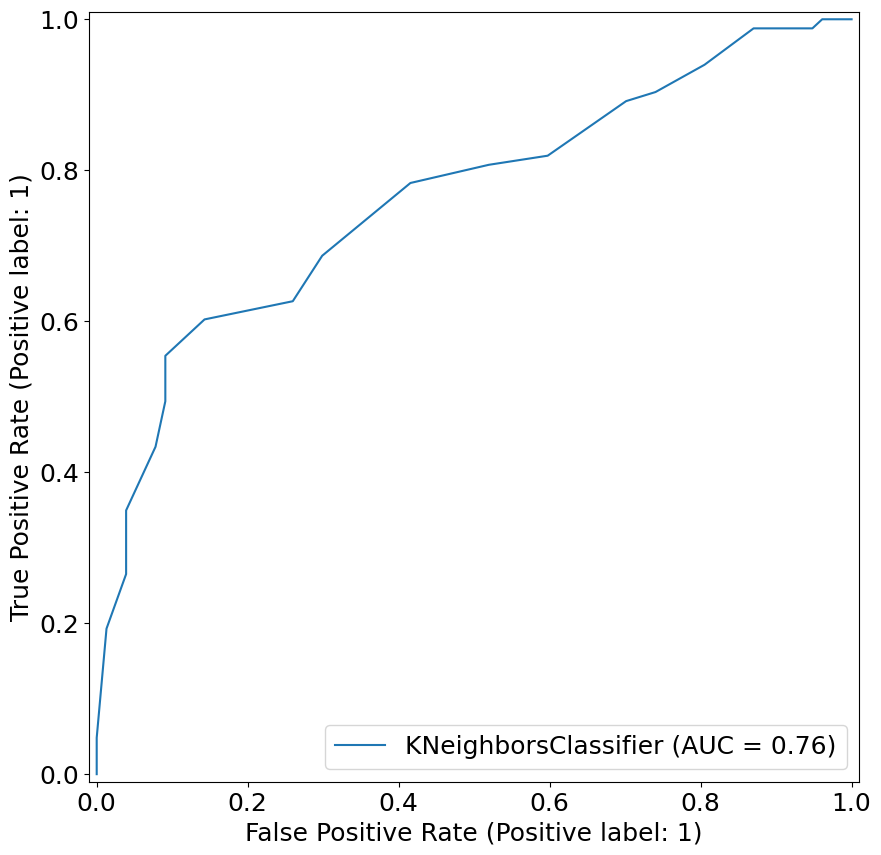

In [13]:
RocCurveDisplay.from_estimator(modelo_kNN.fit(vinhos_treino, classes_treino), vinhos_teste, classes_teste)
plt.show()

Usando a função kernel linear

In [14]:
modelo_SVM = SVC(kernel='linear')
modelo_SVM.fit(vinhos_treino, classes_treino)

SVC(kernel='linear')

In [15]:
predicao_SVM = modelo_SVM.predict(vinhos_teste)
acuracia_SVM = accuracy_score(classes_teste, predicao_SVM)
print('Acuracia de classificação SVM: {}'.format(round(acuracia_SVM, 3)*100)+'%')

Acuracia de classificação SVM: 66.2%


In [16]:
print(classification_report(classes_teste, predicao_SVM))

              precision    recall  f1-score   support

           0       0.64      0.69      0.66        77
           1       0.69      0.64      0.66        83

    accuracy                           0.66       160
   macro avg       0.66      0.66      0.66       160
weighted avg       0.66      0.66      0.66       160



In [17]:
cross_val_score(modelo_SVM, vinhos_treino, classes_treino, cv=10)

array([0.70833333, 0.75694444, 0.70138889, 0.72222222, 0.75      ,
       0.75694444, 0.76388889, 0.77083333, 0.75694444, 0.73426573])

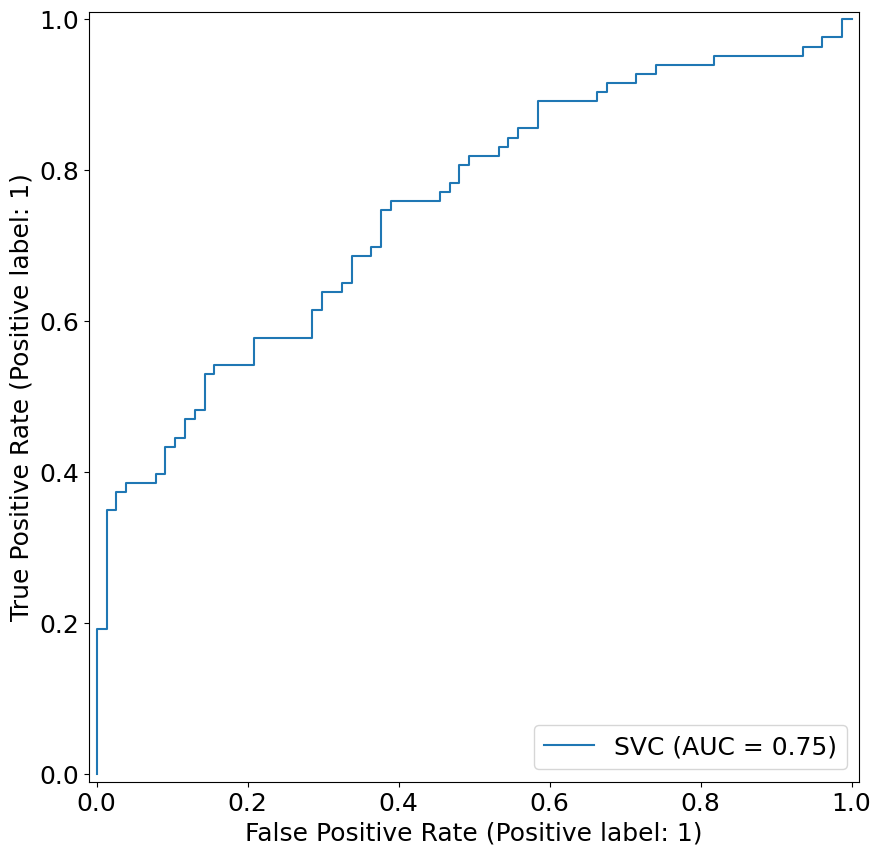

In [18]:
RocCurveDisplay.from_estimator(modelo_SVM.fit(vinhos_treino, classes_treino), vinhos_teste, classes_teste)
plt.show()

Random Forests

In [19]:
modelo_RF = RandomForestClassifier()
modelo_RF.fit(vinhos_treino, classes_treino)

RandomForestClassifier()

In [20]:
predicao_RF = modelo_RF.predict(vinhos_teste)
acuracia_RF = accuracy_score(classes_teste, predicao_RF)
print('Acuracia de classificação RF: {}'.format(round(acuracia_RF, 3)*100)+'%')

Acuracia de classificação RF: 80.0%


In [21]:
print(classification_report(classes_teste, predicao_RF))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79        77
           1       0.80      0.82      0.81        83

    accuracy                           0.80       160
   macro avg       0.80      0.80      0.80       160
weighted avg       0.80      0.80      0.80       160



In [22]:
cross_val_score(modelo_RF, vinhos_treino, classes_treino, cv=10)

array([0.8125    , 0.82638889, 0.79166667, 0.75      , 0.81944444,
       0.86805556, 0.84027778, 0.82638889, 0.79861111, 0.83916084])

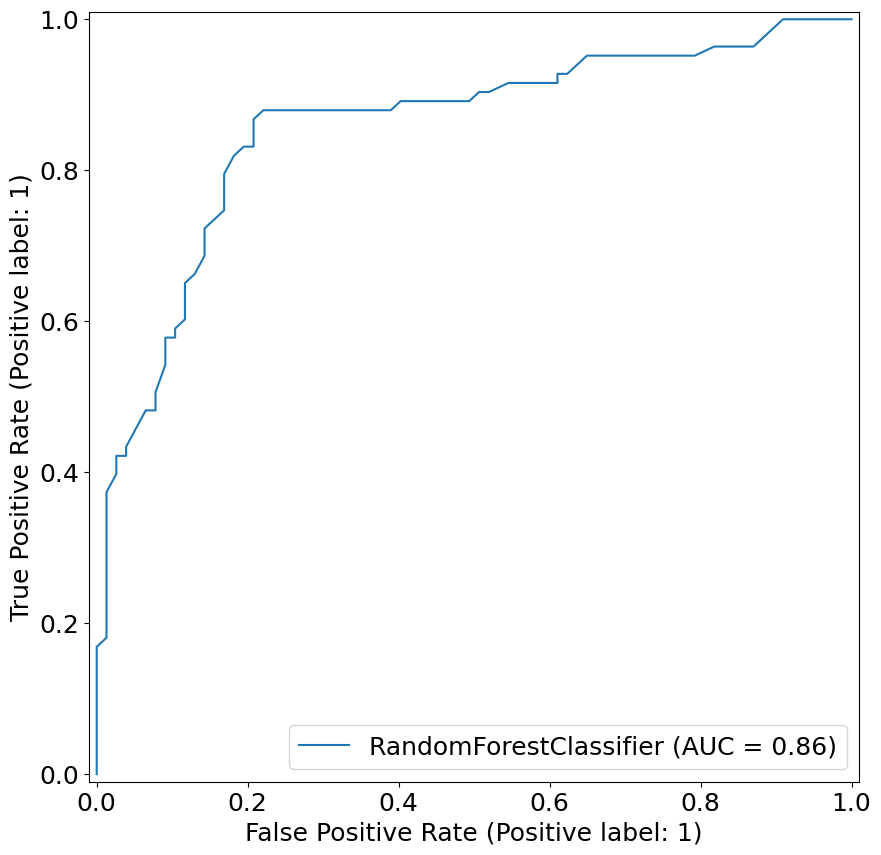

In [23]:
RocCurveDisplay.from_estimator(modelo_RF.fit(vinhos_treino, classes_treino), vinhos_teste, classes_teste)
plt.show()